In [1]:
import re
import string
from collections import Counter
import pandas as pd
import spacy
import textstat

In [2]:
oxford_dict = pd.read_csv('oxford-5k.csv').set_index('word')['level'].to_dict()
oxford_dict

{'a': 'a1',
 'abandon': 'b2',
 'ability': 'a2',
 'able': 'a2',
 'abolish': 'c1',
 'abortion': 'c1',
 'about': 'a1',
 'above': 'a1',
 'abroad': 'a2',
 'absence': 'c1',
 'absent': 'c1',
 'absolute': 'b2',
 'absolutely': 'b1',
 'absorb': 'b2',
 'abstract': 'b2',
 'absurd': 'c1',
 'abundance': 'c1',
 'abuse': 'c1',
 'academic': 'b2',
 'academy': 'c1',
 'accelerate': 'c1',
 'accent': 'b2',
 'accept': 'a2',
 'acceptable': 'b2',
 'acceptance': 'c1',
 'access': 'b1',
 'accessible': 'c1',
 'accident': 'a2',
 'accidentally': 'b2',
 'accommodate': 'b2',
 'accommodation': 'b1',
 'accompany': 'b2',
 'accomplish': 'b2',
 'accomplishment': 'c1',
 'accordance': 'c1',
 'according to': 'a2',
 'accordingly': 'c1',
 'account': 'b2',
 'accountability': 'c1',
 'accountable': 'c1',
 'accountant': 'b2',
 'accounting': nan,
 'accumulate': 'c1',
 'accumulation': 'c1',
 'accuracy': 'b2',
 'accurate': 'b2',
 'accurately': 'b2',
 'accusation': 'c1',
 'accuse': 'b2',
 'accused': 'c1',
 'achieve': 'a2',
 'achievemen

In [4]:
nlp = spacy.load("en_core_web_sm")

In [5]:
def analyze_text(text):
    #предварительная обработка текста
    text = text.lower()
    #удаляем пунктуацию
    text_clean = text.translate(str.maketrans('', '', string.punctuation))
    words = text_clean.split()
    sentences = re.split(r'[.!?]+', text)
    sentences = [s for s in sentences if s.strip()]  # Убираем пустые строки

    #1.общее количество слов
    total_words = len(words)

    #2.средняя длина слова
    if total_words > 0:
        avg_word_length = sum(len(word) for word in words) / total_words
    else:
        avg_word_length = 0

    #3.словарный запас (количество уникальных слов)
    unique_words = set(words)
    vocabulary_size = len(unique_words)

    #4.лексическое разнообразие (отношение уникальных слов к общему числу)
    if total_words > 0:
        lexical_diversity = vocabulary_size / total_words
    else:
        lexical_diversity = 0

    #5.подсчёт слов по уровням
    level_counts = {'a1': 0, 'a2': 0, 'b1': 0, 'b2': 0, 'c1': 0, 'c2': 0}
    for word in words:
        if word in oxford_dict:
            level = oxford_dict[word]
            if level in level_counts:
                level_counts[level] += 1
    
    #вычисляем доли
    if total_words > 0:
        for level in level_counts:
            level_counts[level] = round(level_counts[level] / total_words, 2)

        doc = nlp(text)

    #6.считаем сложные конструкции
    complex_sentences = 0
    passive_constructions = 0

    for sent in doc.sents:
        #признаки сложного предложения (подчинительные союзы, относительные местоимения)
        has_subordinate = any(token.dep_ in ['mark', 'advcl'] for token in sent)
        has_relative = any(token.dep_ == 'relcl' for token in sent)

        if has_subordinate or has_relative:
            complex_sentences += 1

        #пассивный залог
        for token in sent:
            if token.tag_ == 'VBN' and token.head.lemma_ == 'be':
                passive_constructions += 1

    #результаты
    results = {
        'total_words': total_words,
        'avg_word_length': round(avg_word_length, 2),
        'A1_level_words': level_counts['a1'],
        'A2_level_words': level_counts['a2'],
        'B1_level_words': level_counts['b1'],
        'B2_level_words': level_counts['b2'],
        'C1_level_words': level_counts['c1'],
        'C2_level_words': level_counts['c2'],
        'vocabulary_size': vocabulary_size,
        'lexical_diversity': round(lexical_diversity, 2),
        'complex_sentence_ratio': complex_sentences / len(list(doc.sents)) if doc.sents else 0,
        'passive_voice_ratio': passive_constructions / total_words if total_words else 0,
        'flesch_reading_ease': textstat.flesch_reading_ease(text),
        'smog_index': textstat.smog_index(text),
        'coleman_liau_index': textstat.coleman_liau_index(text),
        'sentence_count': textstat.sentence_count(text),
        'lexicon_count': textstat.lexicon_count(text, removepunct=True)
    }
    return results

In [6]:
def estimate_level(results):
    score = 0
    #лексика
    if results['B2_level_words'] >= 0.05 or results['C1_level_words'] >= 0.03 or results['C2_level_words'] >= 0.01:
        score += 2
    elif results['B1_level_words'] >= 0.1:
        score += 1

    #грамматика
    if results.get('complex_sentence_ratio', 0) >= 0.3:
        score += 3
    if results.get('passive_voice_ratio', 0) > 0.02:
        score += 1

    #cтилистика
    if results.get('flesch_reading_ease', 100) >= 60:  # Более сложный текст
        score += 1

    #традиционные метрики
    if results['avg_word_length'] > 4.8:
        score += 1
    if results['lexical_diversity'] >= 0.5:
        score += 1
    print(score)
    #классификация
    if score <= 2:
        return "A1-A2 (Beginner)"
    elif score <= 4:
        return "B1 (Intermediate)"
    elif score <= 6:
        return "B2 (Upper-Intermediate)"
    else:
        return "C1-C2 (Advanced)"

In [14]:
def read_text_from_file(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()
        return text
    except FileNotFoundError:
        print(f"Ошибка: Файл '{file_path}' не найден.")
        return
    except Exception as e:
        print(f"Произошла ошибка при чтении файла: {e}")
        return 

In [15]:
file_path = "C:/Users/boss/Documents/examples/C1_example.txt"  # Укажите путь к вашему файлу
text_from_file = read_text_from_file(file_path)

if text_from_file:  # Если файл успешно прочитан
    analysis = analyze_text(text_from_file)
    level = estimate_level(analysis)

    print("Результаты анализа текста из файла:")
    for key, value in analysis.items():
        print(f"{key}: {value}")
    print(f"\nОценочный уровень английского: {level}")

7
Результаты анализа текста из файла:
total_words: 612
avg_word_length: 4.46
A1_level_words: 0.51
A2_level_words: 0.1
B1_level_words: 0.05
B2_level_words: 0.05
C1_level_words: 0.01
C2_level_words: 0.0
vocabulary_size: 326
lexical_diversity: 0.53
complex_sentence_ratio: 0.5454545454545454
passive_voice_ratio: 0.0032679738562091504
flesch_reading_ease: 60.91207977207978
smog_index: 11.715833242495528
coleman_liau_index: 8.778396072013095
sentence_count: 27
lexicon_count: 611

Оценочный уровень английского: C1-C2 (Advanced)


*Графики*

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
files_to_analyze = ['C:/Users/boss/Documents/examples/A1_test.txt', 'C:/Users/boss/Documents/examples/A1_test_1.txt',\
                    'C:/Users/boss/Documents/examples/A1_test_2.txt', 'C:/Users/boss/Documents/examples/A1_test_3.txt',\
                    'C:/Users/boss/Documents/examples/A2_test.txt', 'C:/Users/boss/Documents/examples/A2_test_2.txt', \
                    'C:/Users/boss/Documents/examples/A2_test_3.txt', 'C:/Users/boss/Documents/examples/B1_test.txt',\
                    'C:/Users/boss/Documents/examples/B1_test_1.txt', 'C:/Users/boss/Documents/examples/B1_test_2.txt',
                    'C:/Users/boss/Documents/examples/B2_test_2.txt', 'C:/Users/boss/Documents/examples/C1_example.txt',\
                    'C:/Users/boss/Documents/examples/C2_test.txt']
results_list = []

# Анализ каждого файла
for file_path in files_to_analyze:
    text_from_file = read_text_from_file(file_path)
    if text_from_file:
        analysis = analyze_text(text_from_file)
        level = estimate_level(analysis)
        analysis['file_name'] = file_path
        analysis['estimated_level'] = level
        results_list.append(analysis)

df_results = pd.DataFrame(results_list)

#первый график: корреляция признаков с уровнем CEFR
#преобразуем уровни в числовые значения
cefr_mapping = {'A1-A2 (Beginner)': 1, 'B1 (Intermediate)': 2, 
                'B2 (Upper-Intermediate)': 3, 'C1-C2 (Advanced)': 4}
df_results['cefr_numeric'] = df_results['estimated_level'].map(cefr_mapping)

feature_columns = ['total_words', 'avg_word_length', 'A1_level_words', 'A2_level_words',
                   'B1_level_words', 'B2_level_words', 'C1_level_words', 'C2_level_words',
                   'vocabulary_size', 'lexical_diversity', 'complex_sentence_ratio',
                   'passive_voice_ratio', 'flesch_reading_ease', 'smog_index',
                   'coleman_liau_index', 'sentence_count', 'lexicon_count']

#вычисляем корреляцию каждого признака с CEFR уровнем
correlations = {}
for feature in feature_columns:
    if feature in df_results.columns:
        correlations[feature] = df_results[feature].corr(df_results['cefr_numeric'])

#создаем DataFrame с корреляциями
corr_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation_with_CEFR'])
corr_df = corr_df.sort_values('Correlation_with_CEFR', ascending=False)

2
3
2
2
1
4
2
5
4
5
6
7
7


C:\Users\boss\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\boss\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [28]:
corr_df

,Feature,Correlation_with_CEFR
6,C1_level_words,0.816582
10,complex_sentence_ratio,0.812498
4,B1_level_words,0.764921
1,avg_word_length,0.762654
13,smog_index,0.759717
14,coleman_liau_index,0.759555
8,vocabulary_size,0.605323
5,B2_level_words,0.598437
3,A2_level_words,0.558053
0,total_words,0.532015


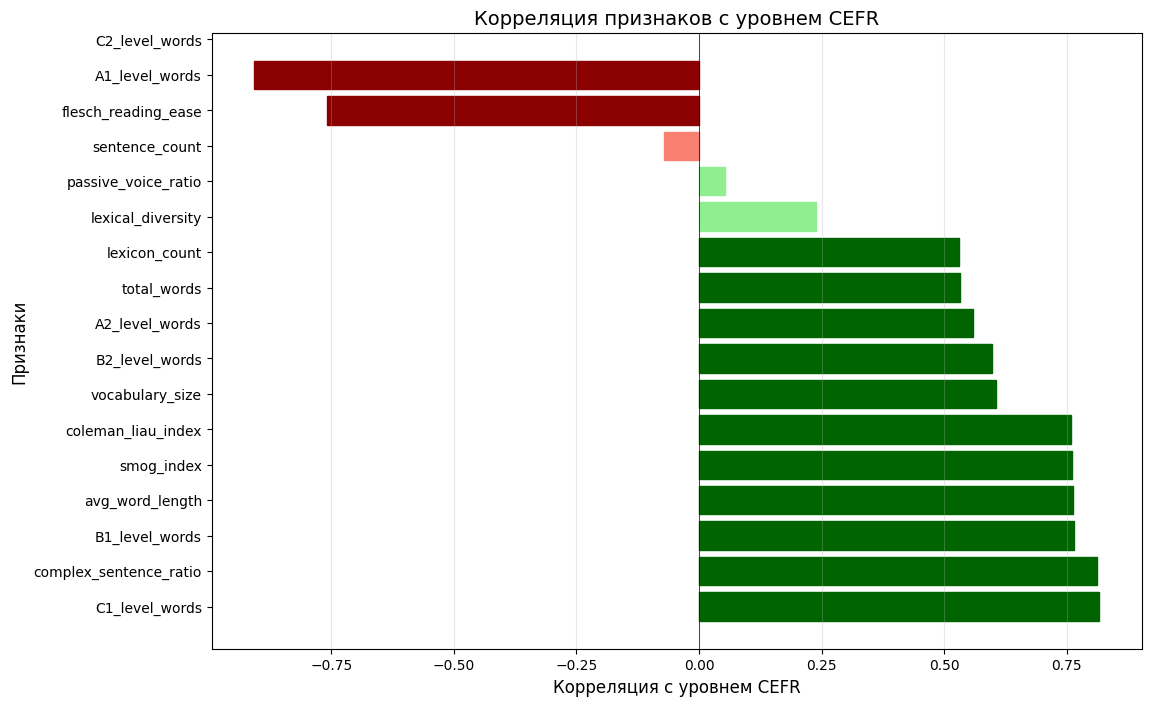

In [26]:
plt.figure(figsize=(12, 8))
bars = plt.barh(corr_df['Feature'], corr_df['Correlation_with_CEFR'])
plt.xlabel('Корреляция с уровнем CEFR', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.title('Корреляция признаков с уровнем CEFR', fontsize=14)

for i, (bar, corr_value) in enumerate(zip(bars, corr_df['Correlation_with_CEFR'])):
    if corr_value > 0.5:
        bar.set_color('darkgreen')
    elif corr_value > 0:
        bar.set_color('lightgreen')
    elif corr_value > -0.3:
        bar.set_color('salmon')
    else:
        bar.set_color('darkred')

plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.savefig('fig_1.png') 

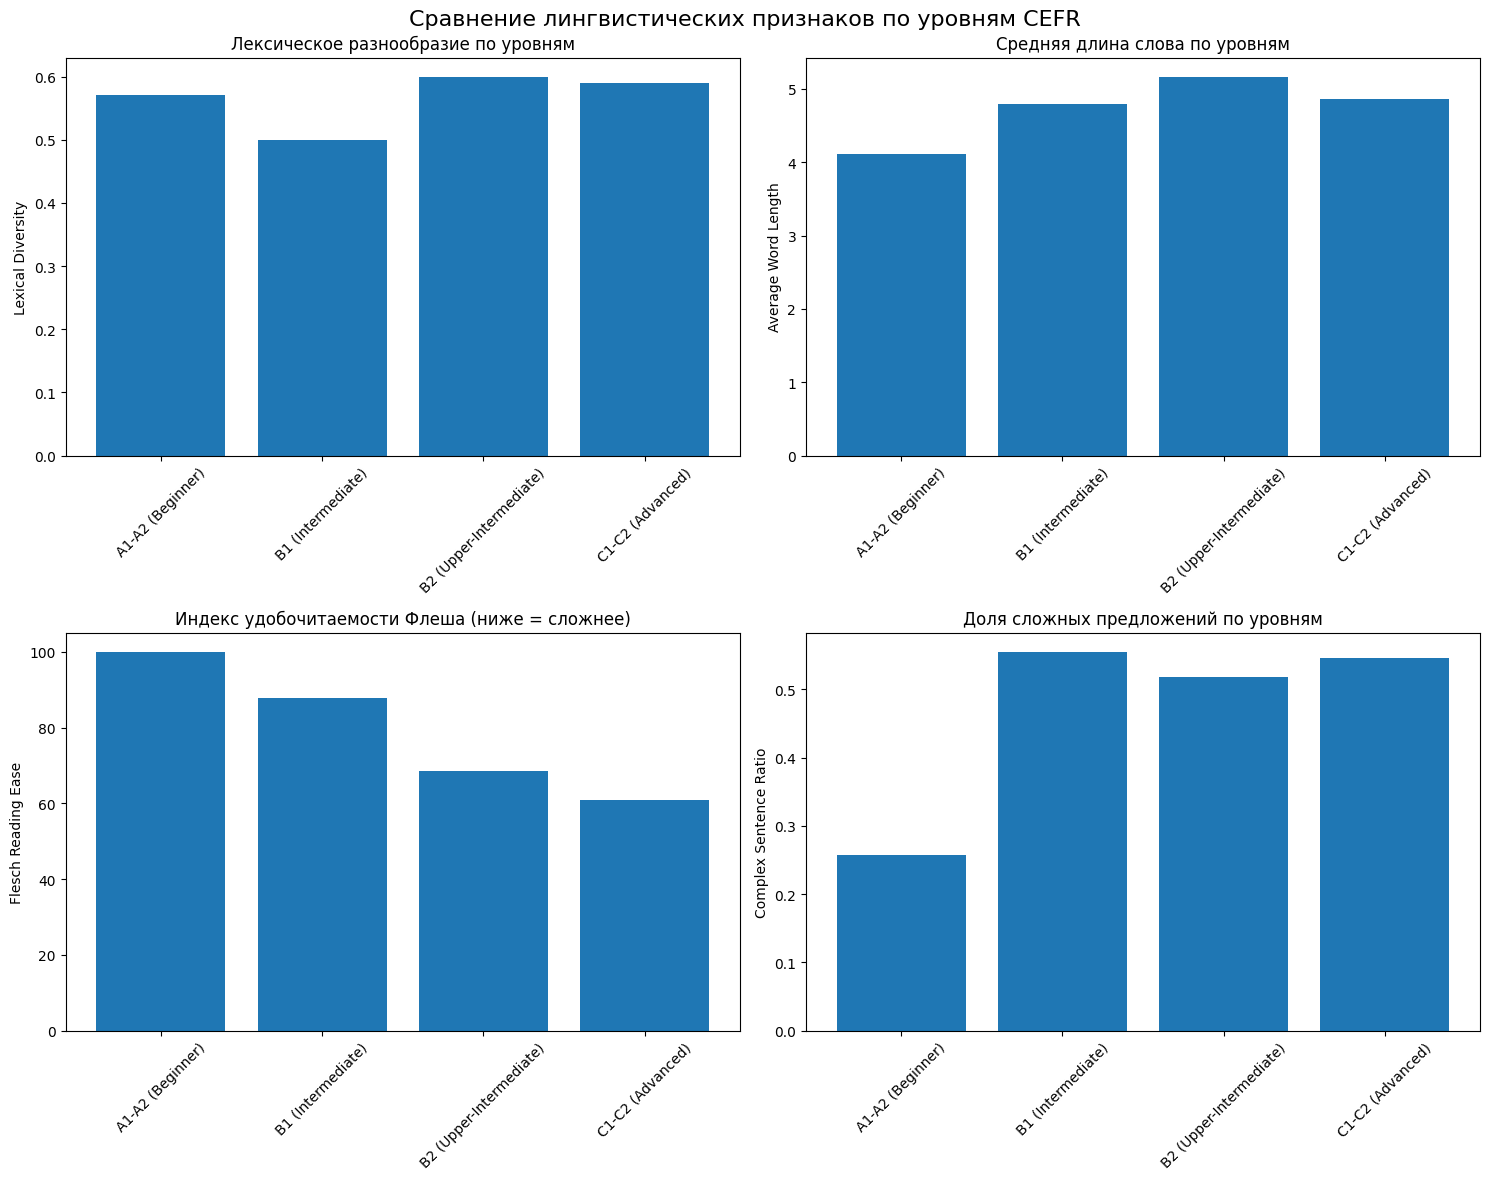

In [27]:
#график сравнение признаков по уровням
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Сравнение лингвистических признаков по уровням CEFR', fontsize=16)

#1 лексическое разнообразие по уровням
if 'lexical_diversity' in df_results.columns:
    axes[0, 0].bar(df_results['estimated_level'], df_results['lexical_diversity'])
    axes[0, 0].set_title('Лексическое разнообразие по уровням')
    axes[0, 0].set_ylabel('Lexical Diversity')
    axes[0, 0].tick_params(axis='x', rotation=45)

#2 средняя длина слова по уровням
if 'avg_word_length' in df_results.columns:
    axes[0, 1].bar(df_results['estimated_level'], df_results['avg_word_length'])
    axes[0, 1].set_title('Средняя длина слова по уровням')
    axes[0, 1].set_ylabel('Average Word Length')
    axes[0, 1].tick_params(axis='x', rotation=45)

#3 индекс удобочитаемости по уровням
if 'flesch_reading_ease' in df_results.columns:
    axes[1, 0].bar(df_results['estimated_level'], df_results['flesch_reading_ease'])
    axes[1, 0].set_title('Индекс удобочитаемости Флеша (ниже = сложнее)')
    axes[1, 0].set_ylabel('Flesch Reading Ease')
    axes[1, 0].tick_params(axis='x', rotation=45)

#4 доля сложных предложений по уровням
if 'complex_sentence_ratio' in df_results.columns:
    axes[1, 1].bar(df_results['estimated_level'], df_results['complex_sentence_ratio'])
    axes[1, 1].set_title('Доля сложных предложений по уровням')
    axes[1, 1].set_ylabel('Complex Sentence Ratio')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_2.png') 